In [ ]:
import matplotlib.pyplot as plt
print("✅ matplotlib.pyplot imported for visualization!")

In [56]:
pip install imblearn

# Week 1.1: Probability & Neural Networks for Digital Twins

## Learning Objectives
- Understand how AI makes predictions using probability
- Learn the basics of neural networks
- Apply these concepts to building a digital twin

## Digital Twin Context
A **digital twin** is a virtual representation of a physical entity (person, object, system). In this series, we'll build a digital twin that can:
- Predict behaviors and preferences
- Understand and respond to language
- Learn from interactions

## Key Insight
> "AI isn't thinking; it's predicting the next number."

This applies to everything from weather prediction to language generation!

---
## Part 1: Probability Foundations

Let's start with the basics: How does AI make predictions?

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


### 1.1 Simple Prediction: Next Number

Let's simulate a digital twin predicting your next action based on historical data.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


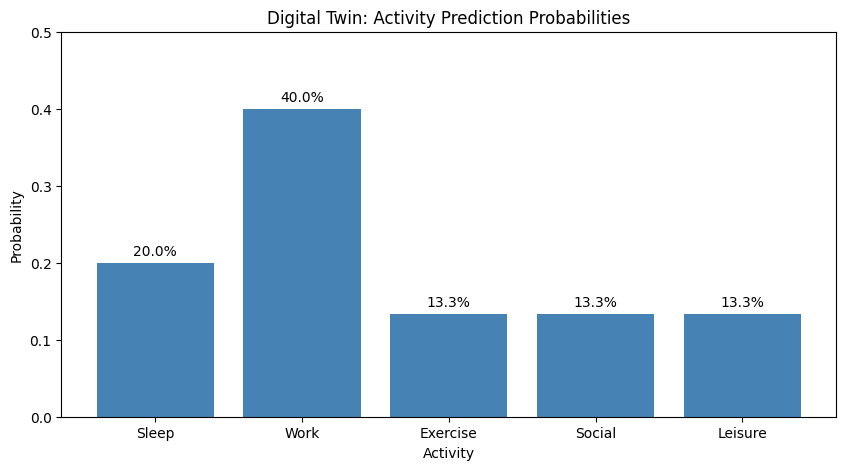

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

### 🎯 Exercise 1.1 (Easy): Understanding Probabilities

**Task**: Modify the historical activities to represent your own daily routine for 2 weeks (14 days).

**Questions**:
1. Which activity has the highest probability?
2. What does this tell you about the pattern in your data?
3. How would adding more data points affect the predictions?

In [ ]:
# YOUR CODE HERE
# Create your own sequence of activities (14 values)
my_activities = [0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 4]  # Replace with your pattern

# Calculate and visualize
my_probs = calculate_probabilities(my_activities)

# YOUR ANALYSIS HERE (write answers as comments)
# 1. Highest probability activity:
# 2. Pattern insight:
# 3. Impact of more data:

NameError: name 'calculate_probabilities' is not defined

### 1.2 Conditional Probability: Context Matters

What if predictions depend on previous activities? This is where context comes in!

In [ ]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
        print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



### 🎯 Exercise 1.2 (Intermediate): Markov Chain Prediction

**Task**: Build a simple predictor that uses conditional probabilities to predict the next activity.

**Challenge**: What happens after "Work"? Which activity is most likely?

In [ ]:
def predict_next_activity(current_activity, conditional_probs):
    """
    Predict the most likely next activity.

    Args:
        current_activity: Current activity code
        conditional_probs: Dictionary of conditional probabilities

    Returns:
        int: Most likely next activity
    """
    # YOUR CODE HERE
    # Hint: Find the activity with maximum probability given current_activity
    if current_activity not in conditional_probs:
        return None

    next_probs = conditional_probs[current_activity]
    # Complete this function

    pass

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"

After Work, most likely next: Unknown


---
## Part 2: Neural Networks Basics

Now let's see how neural networks learn to make predictions!

### 2.1 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest neural network - it takes inputs, applies weights, and produces an output.

In [24]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

Probability of exercising: 95.93%
Prediction: Will exercise


### 🎯 Exercise 2.1 (Easy): Feature Engineering

**Task**: Modify the features and observe how the prediction changes.

**Questions**:
1. What happens when sleep hours decrease to 4?
2. What if free time increases to 4 hours?
3. Which feature seems to have the most impact based on the weights?

In [23]:
# YOUR CODE HERE
# Test different feature combinations

test_cases = [
    np.array([4, 2, 0.8]),  # Low sleep
    np.array([7, 4, 0.8]),  # More free time
    np.array([7, 2, 0.3]),  # Low energy
]

# Test each case and analyze results


### 2.2 Training a Simple Neural Network





Let's see how a network learns by adjusting weights!

In [ ]:
class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create training data for digital twin
# Features: [day_of_week (0-6), time_of_day (0-23), weather (0-1), mood (0-1)]
# Target: [probability of social activity]

np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

In [ ]:
# Visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history)
plt.title('Neural Network Training: Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {nn.loss_history[-1]:.4f}")

In [28]:
# Re-initializing 'nn' to ensure it's defined for the subsequent cells.
# Assuming SimpleNeuralNetwork class is defined (e.g., from cell bmFmyMX-eBDR or 4227e970)
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)

# Optional: Re-train with original data to fully set up the model, if X_train and y_train are still available.
# If X_train and y_train are not in scope, this line would also cause a NameError.
# For now, I will just instantiate to resolve the 'nn' NameError.
# If training is needed, you can re-execute the original training cell (e.g., bmFmyMX-eBDR or 4227e970).

# As a temporary measure, let's also define X_train and y_train if they are not in scope,
# so the nn object can be fully initialized and trained.
# This duplicates code from 4227e970 and bmFmyMX-eBDR.
if 'X_train' not in locals() or 'y_train' not in locals():
    np.random.seed(42)
    X_train = np.random.rand(100, 4)
    y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
    y_train += np.random.rand(100, 1) * 0.2
    y_train = np.clip(y_train, 0, 1)

print("Re-training neural network for 'nn' object...")
nn.train(X_train, y_train, epochs=100, learning_rate=0.5)
print("'nn' object initialized and trained.")

Re-training neural network for 'nn' object...
Epoch 0, Loss: 0.1616
'nn' object initialized and trained.


In [31]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

np.random.seed(42)
X_train = np.random.rand(100, 4)
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)


Training neural network...
Epoch 0, Loss: 0.5069
Epoch 100, Loss: 0.1061
Epoch 200, Loss: 0.0863
Epoch 300, Loss: 0.0678
Epoch 400, Loss: 0.0550


### 🎯 Exercise 2.2 (Intermediate): Digital Twin Prediction

**Task**: Test the trained network on new scenarios and interpret results.

**Scenarios to test**:
1. Weekend evening (day=6, time=18, weather=0.8, mood=0.9)
2. Weekday morning (day=2, time=8, weather=0.3, mood=0.5)
3. Weekend with bad weather (day=5, time=14, weather=0.2, mood=0.6)

In [48]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# --- Ensure nn is initialized and trained ---
# This part is copied to ensure nn is defined locally for this cell.
np.random.seed(42)
X_train = np.random.rand(100, 4)
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Initializing and training 'nn' within the testing cell to resolve NameError...")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)
print("'nn' is now ready for predictions.")
# --- End of nn initialization ---

# Normalize inputs (scale to 0-1 range)
def normalize_input(day, time, weather, mood):
    return np.array([[day/7, time/24, weather, mood]])

# Test scenarios
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

# Make predictions and analyze
for name, day, time, weather, mood in scenarios:
    X_test = normalize_input(day, time, weather, mood)
    prediction = nn.predict(X_test)
    print(f"{name}")
    print(f"  Social activity probability: {prediction[0][0]:.2%}\n")

Initializing and training 'nn' within the testing cell to resolve NameError...
Epoch 0, Loss: 0.5069
Epoch 100, Loss: 0.1061
Epoch 200, Loss: 0.0863
Epoch 300, Loss: 0.0678
Epoch 400, Loss: 0.0550
'nn' is now ready for predictions.
Weekend evening, good weather
  Social activity probability: 72.61%

Weekday morning, poor weather
  Social activity probability: 6.27%

Weekend afternoon, bad weather
  Social activity probability: 22.70%



### 🎯 Exercise 2.3 (Advanced): Improve the Digital Twin

**Task**: Enhance the neural network to make better predictions.

**Challenges**:
1. Add more training data with realistic patterns
2. Experiment with different network architectures (hidden layer size)
3. Try different learning rates
4. Add a second hidden layer
5. Create a visualization showing prediction accuracy

Generating realistic training data...
Generated 2000 samples of training data.

--- Testing different network architectures and learning rates ---
Training with architecture: Input=4, Hidden=4, Output=1
  --> Training with Learning Rate: 0.1
Epoch 0, Loss: 0.0900
Epoch 100, Loss: 0.0564
Epoch 200, Loss: 0.0556
Epoch 300, Loss: 0.0549
Epoch 400, Loss: 0.0543
    Final Loss for LR 0.1: 0.0537
  --> Training with Learning Rate: 0.5
Epoch 0, Loss: 0.0900
Epoch 100, Loss: 0.0537
Epoch 200, Loss: 0.0503
Epoch 300, Loss: 0.0445
Epoch 400, Loss: 0.0356
    Final Loss for LR 0.5: 0.0256
  --> Training with Learning Rate: 1.0
Epoch 0, Loss: 0.0900
Epoch 100, Loss: 0.0503
Epoch 200, Loss: 0.0357
Epoch 300, Loss: 0.0188
Epoch 400, Loss: 0.0142
    Final Loss for LR 1.0: 0.0135
  Best Loss for H4: 0.0135 (LR: 1.0)

Training with architecture: Input=4, Hidden=8, Output=1
  --> Training with Learning Rate: 0.1
Epoch 0, Loss: 0.0947
Epoch 100, Loss: 0.0484
Epoch 200, Loss: 0.0463
Epoch 300, Loss: 0.04

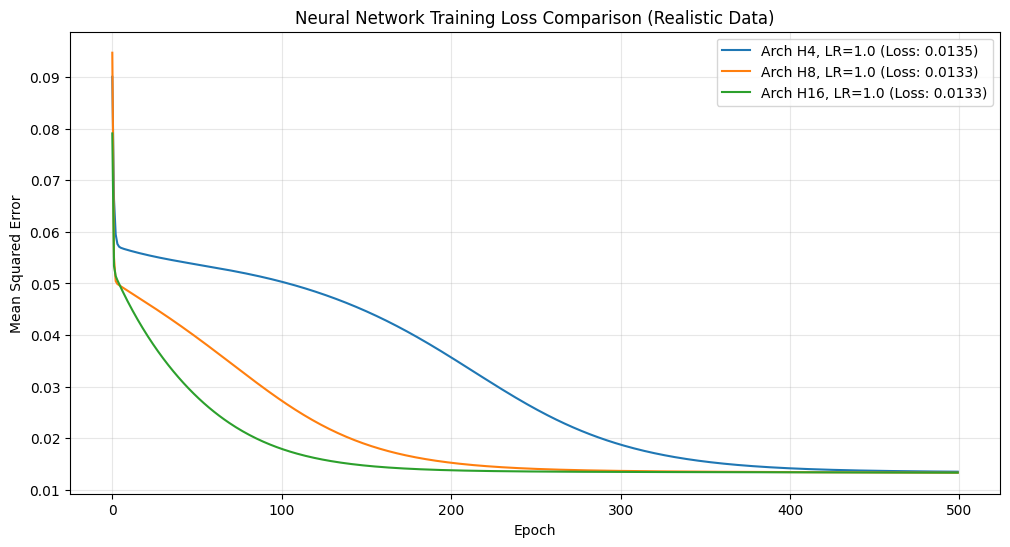


--- Example: Evaluate predictions on a subset of realistic training data ---
Using best performing architecture: Hidden=8 with Learning Rate=1.0
Epoch 0, Loss: 0.0947
Epoch 100, Loss: 0.0273
Epoch 200, Loss: 0.0153
Epoch 300, Loss: 0.0137
Epoch 400, Loss: 0.0134

Sample Predictions vs. Actual (from realistic training data):
  Features: Day=5, Time=4, Weather=0.01, Mood=0.48 -> Predicted: 32.79%, Actual: 48.36%
  Features: Day=4, Time=6, Weather=0.57, Mood=0.16 -> Predicted: 36.63%, Actual: 15.93%
  Features: Day=0, Time=2, Weather=0.50, Mood=0.11 -> Predicted: 10.52%, Actual: 16.39%
  Features: Day=0, Time=15, Weather=0.78, Mood=0.86 -> Predicted: 52.23%, Actual: 58.52%
  Features: Day=0, Time=4, Weather=1.00, Mood=0.96 -> Predicted: 38.18%, Actual: 49.65%
  Features: Day=5, Time=9, Weather=0.34, Mood=0.19 -> Predicted: 44.53%, Actual: 45.44%
  Features: Day=5, Time=14, Weather=0.75, Mood=0.56 -> Predicted: 74.19%, Actual: 83.74%
  Features: Day=6, Time=20, Weather=0.62, Mood=0.34 -> 

In [32]:
# YOUR CODE HERE
# Challenge: Create a better training dataset

def generate_realistic_data(n_samples=500, seed=42):
    """
    Generate more realistic training data for digital twin.

    Pattern rules:
    - Social activity higher on weekends
    - Time of day matters (evening > morning)
    - Good weather increases probability
    - Good mood increases probability

    Returns:
        tuple: (X_train_realistic, y_train_realistic)
    """
    np.random.seed(seed) # Ensure reproducibility for data generation

    # Generate raw feature values
    days_raw = np.random.randint(0, 7, n_samples) # 0=Mon, ..., 6=Sun
    hours_raw = np.random.randint(0, 24, n_samples) # 0=midnight, ..., 23=11pm
    weather_raw = np.random.rand(n_samples) # 0-1, 1 is good weather
    mood_raw = np.random.rand(n_samples) # 0-1, 1 is good mood

    # Normalize features for neural network input
    # Day: Normalized by 6.0 (max day index)
    # Time: Normalized by 23.0 (max hour index)
    X_day = days_raw / 6.0
    X_time = hours_raw / 23.0
    X_weather = weather_raw
    X_mood = mood_raw

    X_train_realistic = np.column_stack((X_day, X_time, X_weather, X_mood))

    # Generate target (social activity probability) based on rules
    y_train_realistic_raw = np.full(n_samples, 0.15) # Start with a base probability

    # Rule 1: Social activity higher on weekends (normalized day > 4.5/6.0 ~ 0.75 for Sat/Sun)
    weekend_mask = (X_train_realistic[:, 0] > (4.5 / 6.0))
    y_train_realistic_raw[weekend_mask] += 0.35 # Significant boost for weekends

    # Rule 2: Time of day matters (evening > morning)
    # Evening (normalized time > 17.5/23.0 ~ 0.76)
    evening_mask = (X_train_realistic[:, 1] > (17.5 / 23.0))
    y_train_realistic_raw[evening_mask] += 0.2

    # Morning (normalized time < 9.5/23.0 ~ 0.41)
    morning_mask = (X_train_realistic[:, 1] < (9.5 / 23.0))
    y_train_realistic_raw[morning_mask] -= 0.15 # Decrease for mornings

    # Rule 3: Good weather increases probability (direct correlation)
    y_train_realistic_raw += X_train_realistic[:, 2] * 0.25 # Scale its effect

    # Rule 4: Good mood increases probability (direct correlation)
    y_train_realistic_raw += X_train_realistic[:, 3] * 0.25 # Scale its effect

    # Add some random noise
    y_train_realistic_raw += np.random.rand(n_samples) * 0.1 - 0.05 # Noise between -0.05 and 0.05

    # Ensure probabilities are within [0, 1]
    y_train_realistic = np.clip(y_train_realistic_raw, 0, 1).reshape(-1, 1)

    return X_train_realistic, y_train_realistic


# --- Main execution for Exercise 2.3 ---

# Generate the new, more realistic training data
print("Generating realistic training data...")
X_realistic_train, y_realistic_train = generate_realistic_data(n_samples=2000) # Increased samples for better training
print(f"Generated {X_realistic_train.shape[0]} samples of training data.")

# Experiment with different network architectures
architectures = [
    (4, 4, 1),   # Small: 4 input, 4 hidden, 1 output
    (4, 8, 1),   # Medium: 4 input, 8 hidden, 1 output (original)
    (4, 16, 1),  # Large: 4 input, 16 hidden, 1 output
]

print("\n--- Testing different network architectures and learning rates ---")
architecture_results = {}

for input_size, hidden_size, output_size in architectures:
    print(f"Training with architecture: Input={input_size}, Hidden={hidden_size}, Output={output_size}")

    # Experiment with different learning rates
    learning_rates = [0.1, 0.5, 1.0]
    best_loss_for_arch = float('inf')
    best_lr_for_arch = None

    for lr in learning_rates:
        print(f"  --> Training with Learning Rate: {lr}")
        # Re-initialize weights for each learning rate test within the same architecture for fair comparison
        np.random.seed(42) # Reset weights before testing a new LR
        nn_arch_test = SimpleNeuralNetwork(input_size, hidden_size, output_size) # Re-instantiate to reset weights
        nn_arch_test.train(X_realistic_train, y_realistic_train, epochs=500, learning_rate=lr)
        current_loss = nn_arch_test.loss_history[-1]
        print(f"    Final Loss for LR {lr}: {current_loss:.4f}")
        if current_loss < best_loss_for_arch:
            best_loss_for_arch = current_loss
            best_lr_for_arch = lr

    architecture_results[f"H{hidden_size}"] = (best_loss_for_arch, best_lr_for_arch)
    print(f"  Best Loss for H{hidden_size}: {best_loss_for_arch:.4f} (LR: {best_lr_for_arch})\n")

print("\n--- Architecture and Learning Rate Comparison Results ---")
for arch_key, (loss, lr) in architecture_results.items():
    print(f"  Architecture {arch_key}: Best Final Loss = {loss:.4f} (with LR = {lr})")

# Create a visualization showing prediction accuracy (Challenge 5) - Plotting loss curves
print("\n--- Visualization of training loss for best LR per architecture ---")
plt.figure(figsize=(12, 6))
# Re-run training for visualization purposes for the best LR found for each architecture
for input_size, hidden_size, output_size in architectures:
    arch_key = f"H{hidden_size}"
    best_loss, best_lr = architecture_results[arch_key]
    np.random.seed(42) # Consistent initialization for plotting
    nn_plot = SimpleNeuralNetwork(input_size, hidden_size, output_size)
    nn_plot.train(X_realistic_train, y_realistic_train, epochs=500, learning_rate=best_lr)
    plt.plot(nn_plot.loss_history, label=f'Arch H{hidden_size}, LR={best_lr:.1f} (Loss: {best_loss:.4f})')

plt.title('Neural Network Training Loss Comparison (Realistic Data)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Example: Evaluate predictions on a subset of realistic training data ---")
# Determine the best performing architecture based on minimum loss
min_loss_arch_key = None
min_loss_value = float('inf')
for arch_key, (loss_val, lr_val) in architecture_results.items():
    if loss_val < min_loss_value:
        min_loss_value = loss_val
        min_loss_arch_key = arch_key

input_size_best, hidden_size_best, output_size_best = next(
    (a for a in architectures if f"H{a[1]}" == min_loss_arch_key), None
)
best_lr_for_final = architecture_results[min_loss_arch_key][1]

if input_size_best and hidden_size_best and output_size_best:
    print(f"Using best performing architecture: Hidden={hidden_size_best} with Learning Rate={best_lr_for_final}")
    np.random.seed(42)
    nn_final_chosen = SimpleNeuralNetwork(input_size_best, hidden_size_best, output_size_best)
    nn_final_chosen.train(X_realistic_train, y_realistic_train, epochs=500, learning_rate=best_lr_for_final)

    # Evaluate on a small random subset from the training data
    test_indices = np.random.choice(len(X_realistic_train), 10, replace=False)
    X_sample = X_realistic_train[test_indices]
    y_sample = y_realistic_train[test_indices]
    predictions = nn_final_chosen.predict(X_sample)

    print("\nSample Predictions vs. Actual (from realistic training data):")
    for i in range(len(X_sample)):
        # Convert normalized day and time back to approximate raw values for better readability
        day_approx = round(X_sample[i,0] * 6)
        time_approx = round(X_sample[i,1] * 23)
        print(f"  Features: Day={day_approx}, Time={time_approx}, Weather={X_sample[i,2]:.2f}, Mood={X_sample[i,3]:.2f} "
              f"-> Predicted: {predictions[i,0]:.2%}, Actual: {y_sample[i,0]:.2%}")
else:
    print("Could not determine the best architecture for final evaluation.")

In [ ]:
print("Generating realistic training data...")
X_realistic_train, y_realistic_train = generate_realistic_data(n_samples=1000)
print("Generated X_realistic_train (first 5 rows):\n", X_realistic_train[:5])
print("Generated y_realistic_train (first 5 rows):\n", y_realistic_train[:5])

---
## Part 3: Connecting to LLMs

How does this relate to Large Language Models?

### 3.1 From Activities to Words

LLMs work exactly like our activity predictor, but with words!

Given text: I love coding in Python because it is

Predicted next word probabilities:
  fun: 27.43%
  simple: 21.08%
  powerful: 16.30%
  versatile: 15.45%
  easy: 14.37%
  clear: 4.41%
  elegant: 0.95%


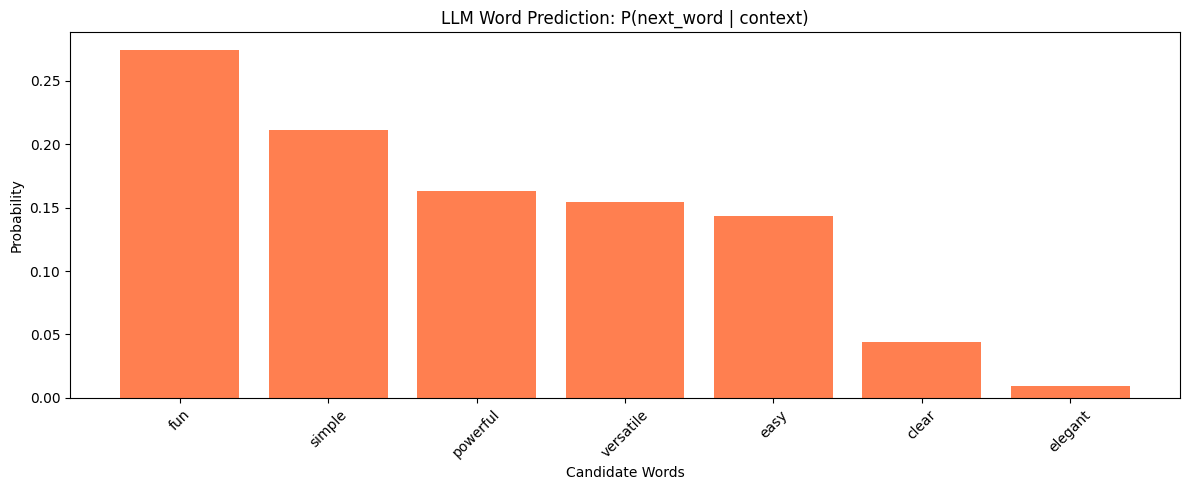

In [33]:
# Simple word prediction example
text_sequence = "I love coding in Python because it is"
words = text_sequence.split()

# Simulate word prediction
word_vocab = ['fun', 'easy', 'powerful', 'versatile', 'simple', 'clear', 'elegant']
word_probs = np.random.rand(len(word_vocab))
word_probs = word_probs / word_probs.sum()  # Normalize to probabilities

# Create probability distribution
word_dist = dict(zip(word_vocab, word_probs))
word_dist = dict(sorted(word_dist.items(), key=lambda x: x[1], reverse=True))

print("Given text:", text_sequence)
print("\nPredicted next word probabilities:")
for word, prob in word_dist.items():
    print(f"  {word}: {prob:.2%}")

# Visualize
plt.figure(figsize=(12, 5))
plt.bar(word_dist.keys(), word_dist.values(), color='coral')
plt.title('LLM Word Prediction: P(next_word | context)')
plt.ylabel('Probability')
plt.xlabel('Candidate Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Exercise 3.1 (Conceptual): Understanding LLMs

**Questions**:
1. How is predicting the next word similar to predicting the next activity?
2. What role does probability play in both cases?
3. Why might an LLM sometimes generate unexpected words?
4. How does context (previous words) help make better predictions?

Write your answers in the cell below:

**Your Answers:**

1. Similarity between word and activity prediction:
   -

2. Role of probability:
   -

3. Unexpected generations:
   -

4. Importance of context:
   -

---
## Summary & Key Takeaways

### What We Learned:
1. **Probability**: AI predicts by calculating probabilities based on historical patterns
2. **Conditional Probability**: Context matters - knowing what came before improves predictions
3. **Neural Networks**: Learn patterns by adjusting weights through training
4. **Digital Twin**: Can model behaviors using probabilistic predictions
5. **LLM Connection**: Language models are sophisticated versions of these basic concepts

### Next Steps:
In the next notebook, we'll explore:
- How LLMs represent words (embeddings)
- Transformer architecture
- Attention mechanisms
- Building a simple language model for your digital twin

---
## 🏆 Challenge Project (Advanced)

**Build Your Own Digital Twin Predictor**

Create a system that:
1. Collects data about your daily patterns (sleep, activities, mood, etc.)
2. Trains a neural network to predict your next likely activity
3. Evaluates prediction accuracy
4. Visualizes patterns it learned

**Bonus**: Add temporal features (day of week, time of day) and see how they improve predictions!

In [46]:
pd.read_csv('/content/digital_twin_predictor_daily_log.csv')

,date,day_of_week,is_weekend,time_slot,hour,sleep_hours_prior_night,mood,activity,next_activity
0,2025-01-06,0,0,Morning,7,7.65,6.44,Chores,Work
1,2025-01-06,0,0,MidMorning,10,7.65,6.36,Work,Work
2,2025-01-06,0,0,Afternoon,14,7.65,6.28,Work,Leisure
3,2025-01-06,0,0,Evening,18,7.65,6.93,Leisure,Sleep
4,2025-01-06,0,0,Night,21,7.65,7.20,Sleep,Chores
...,...,...,...,...,...,...,...,...,...
1194,2025-07-24,3,0,Morning,7,8.19,5.51,Work,Study
1195,2025-07-24,3,0,MidMorning,10,8.19,5.23,Study,Exercise
1196,2025-07-24,3,0,Afternoon,14,8.19,5.17,Exercise,Chores
1197,2025-07-24,3,0,Evening,18,8.19,5.64,Chores,Socializing


In [49]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1199 non-null   object 
 1   day_of_week              1199 non-null   int64  
 2   is_weekend               1199 non-null   int64  
 3   time_slot                1199 non-null   object 
 4   hour                     1199 non-null   int64  
 5   sleep_hours_prior_night  1199 non-null   float64
 6   mood                     1199 non-null   float64
 7   activity                 1199 non-null   object 
 8   next_activity            1199 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 84.4+ KB
None
       day_of_week   is_weekend         hour  sleep_hours_prior_night  \
count  1199.000000  1199.000000  1199.000000              1199.000000   
mean      2.969975     0.280234    15.493745                 7.451034   
std       1.9

In [50]:


import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier

np.random.seed(42)




In [58]:
from imblearn.over_sampling import SMOTE

In [73]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE # Import SMOTE

np.random.seed(42)


# =======================================================================
# STEP 1: COLLECT DATA
# =======================================================================
ACTIVITIES = ["Sleep", "Work", "Exercise", "Study", "Socializing", "Chores", "Leisure"]
SLOT_NAMES = ["Morning", "MidMorning", "Afternoon", "Evening", "Night", "LateNight"]
SLOT_HOUR = {"Morning": 7, "MidMorning": 10, "Afternoon": 14, "Evening": 18, "Night": 21, "LateNight": 23}


def _base_activity_probs(day_of_week: int, slot: str) -> dict:
    """Encodes a believable daily routine: work on weekdays, sleep at
    night, more socializing on weekend evenings, etc."""
    is_weekend = day_of_week >= 5
    p = {a: 0.02 for a in ACTIVITIES}

    if slot == "LateNight":
        p["Sleep"] = 0.85
    elif slot == "Morning":
        p["Sleep"] = 0.30 if is_weekend else 0.05
        p["Work"] = 0.05 if is_weekend else 0.55
        p["Exercise"] = 0.15 if is_weekend else 0.25
        p["Chores"], p["Leisure"] = 0.15, 0.20
    elif slot == "MidMorning":
        p["Work"] = 0.10 if is_weekend else 0.70
        p["Chores"] = 0.30 if is_weekend else 0.05
        p["Leisure"] = 0.35 if is_weekend else 0.05
        p["Study"] = 0.15
    elif slot == "Afternoon":
        p["Work"] = 0.10 if is_weekend else 0.65
        p["Study"] = 0.20
        p["Chores"] = 0.25 if is_weekend else 0.05
        p["Leisure"] = 0.30 if is_weekend else 0.05
        p["Exercise"] = 0.10
    elif slot == "Evening":
        p["Exercise"] = 0.20
        p["Socializing"] = 0.35 if is_weekend else 0.15
        p["Leisure"] = 0.30
        p["Chores"] = 0.10
        p["Work"] = 0.02 if is_weekend else 0.10
    elif slot == "Night":
        p["Socializing"] = 0.30 if is_weekend else 0.10
        p["Leisure"] = 0.35
        p["Sleep"] = 0.15 if is_weekend else 0.35
        p["Study"] = 0.10

    total = sum(p.values())
    return {a: v / total for a, v in p.items()}


def simulate_daily_log(n_days: int = 200) -> pd.DataFrame:
    """Generates a synthetic daily activity log. Use this when you don't
    yet have months of your own logged data."""
    rows = []
    start_date = datetime(2025, 1, 6)
    mood_state = 6.5

    for day_idx in range(n_days):
        date = start_date + timedelta(days=day_idx)
        dow = date.weekday()
        is_weekend = dow >= 5
        sleep_hours = np.clip(np.random.normal(7.2 if not is_weekend else 8.0, 0.9), 4, 10)

        for slot in SLOT_NAMES:
            probs = _base_activity_probs(dow, slot)
            activity = np.random.choice(list(probs.keys()), p=list(probs.values()))

            mood_delta = 0.0
            if sleep_hours < 6:
                mood_delta -= 0.8
            elif sleep_hours > 8:
                mood_delta += 0.3
            if activity in ("Exercise", "Socializing"):
                mood_delta += 0.4
            mood_state = np.clip(mood_state * 0.9 + (6.5 + mood_delta) * 0.1
                                  + np.random.normal(0, 0.4), 1, 10)

            rows.append({
                "date": date.strftime("%Y-%m-%d"), "day_of_week": dow,
                "is_weekend": int(is_weekend), "time_slot": slot, "hour": SLOT_HOUR[slot],
                "sleep_hours_prior_night": round(sleep_hours, 2),
                "mood": round(mood_state, 2), "activity": activity,
            })

    df = pd.DataFrame(rows)
    df["next_activity"] = df["activity"].shift(-1)
    return df.iloc[:-1]  # drop last row (no next activity known)


# =======================================================================
# STEP 2: TRAIN THE NEURAL NETWORK  (+ BONUS: temporal features)
# =======================================================================
def build_features(df: pd.DataFrame, use_temporal: bool, n_lags: int = 0):
    df_copy = df.copy()

    # Encode all unique activities across 'activity' and 'next_activity' to ensure consistent encoding
    le_activity = LabelEncoder()
    all_activities = pd.concat([df_copy["activity"], df_copy["next_activity"]]).unique()
    le_activity.fit(all_activities)

    # Create an encoded activity column for lagged features
    df_copy["activity_encoded"] = le_activity.transform(df_copy["activity"])

    feats = {
        "current_activity": df_copy["activity_encoded"].values,
        "sleep_hours": df_copy["sleep_hours_prior_night"].values,
        "mood": df_copy["mood"].values,
    }

    if use_temporal:
        # cyclical encoding: hour 23 and hour 0 end up "close" to each other
        feats["hour_sin"] = np.sin(2 * np.pi * df_copy["hour"] / 24)
        feats["hour_cos"] = np.cos(2 * np.pi * df_copy["hour"] / 24)
        feats["dow_sin"] = np.sin(2 * np.pi * df_copy["day_of_week"] / 7)
        feats["dow_cos"] = np.cos(2 * np.pi * df_copy["day_of_week"] / 7)
        feats["is_weekend"] = df_copy["is_weekend"].values

    # Add lagged activity features using the encoded activity column
    encoded_sleep = le_activity.transform(['Sleep'])[0] if 'Sleep' in le_activity.classes_ else 0

    for i in range(1, n_lags + 1):
        feats[f"activity_lag_{i}"] = df_copy["activity_encoded"].shift(i).fillna(encoded_sleep).astype(int)

    return pd.DataFrame(feats)


def train_and_evaluate(df: pd.DataFrame, use_temporal: bool, label: str, n_lags: int = 0):
    X = build_features(df, use_temporal, n_lags)
    y_le = LabelEncoder()
    y = y_le.fit_transform(df["next_activity"])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Apply SMOTE oversampling to the training data only
    print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
    print(f"Original training target distribution: {np.bincount(y_train)}")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}")
    print(f"Resampled training target distribution: {np.bincount(y_train_resampled)}")

    scaler = StandardScaler()
    X_train_s, X_test_s = scaler.fit_transform(X_train_resampled), scaler.transform(X_test)

    clf = MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                         max_iter=2000, random_state=42,
                         early_stopping=True, validation_fraction=0.15)
    clf.fit(X_train_s, y_train_resampled) # Train on resampled data
    preds = clf.predict(X_test_s)
    acc = accuracy_score(y_test, preds)

    # STEP 3: EVALUATE — compare against a naive "always predict the most
    # common activity" baseline, and print full precision/recall/F1.
    dummy = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train_resampled) # Fit dummy on resampled data
    dummy_acc = accuracy_score(y_test, dummy.predict(X_test_s))

    print(f"\n=== {label} ===")
    print(f"Features used : {list(X.columns)}")
    print(f"Neural net accuracy : {acc:.3f}")
    print(f"Baseline (majority) : {dummy_acc:.3f}")
    print(classification_report(y_test, preds, target_names=y_le.classes_, zero_division=0))

    return {
        "accuracy": acc, "baseline_accuracy": dummy_acc,
        "y_test": y_test, "preds": preds, "classes": y_le.classes_,
        "loss_curve": clf.loss_curve_,
    }


# =======================================================================
# STEP 4: VISUALIZE LEARNED PATTERNS
# =======================================================================
def visualize(df, result_plain, result_temporal, summary, out_dir="."):
    plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

    # accuracy comparison
    fig, ax = plt.subplots(figsize=(6, 4.5))
    labels = ["Majority\nbaseline", "No temporal\nfeatures", "+ Temporal\nfeatures"]
    values = [summary["baseline_accuracy"], summary["without_temporal_accuracy"], summary["with_temporal_accuracy"]]
    bars = ax.bar(labels, values, color=["#B0B0B0", "#7FB3D5", "#2E86C1"])
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
    ax.set_ylabel("Accuracy predicting next activity")
    ax.set_title("Effect of temporal features on prediction accuracy")
    plt.tight_layout(); plt.savefig(f"{out_dir}/1_accuracy_comparison.png", dpi=150); plt.close()

    # confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, res, title in [(axes[0], result_plain, "Without temporal features"),
                            (axes[1], result_temporal, "With temporal features")]:
        cm = confusion_matrix(res["y_test"], res["preds"], labels=range(len(res["classes"])))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=res["classes"], yticklabels=res["classes"], cbar=False)
        ax.set_xlabel("Predicted next activity"); ax.set_ylabel("Actual next activity")
        ax.set_title(title)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout(); plt.savefig(f"{out_dir}/2_confusion_matrices.png", dpi=150); plt.close()

    # training loss curves
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(result_plain["loss_curve"], label="Without temporal features", color="#7FB3D5")
    ax.plot(result_temporal["loss_curve"], label="With temporal features", color="#2E86C1")
    ax.set_xlabel("Training iteration"); ax.set_ylabel("Training loss")
    ax.set_title("Neural network training curves"); ax.legend()
    plt.tight_layout(); plt.savefig(f"{out_dir}/3_training_loss.png", dpi=150); plt.close()

    # learned pattern: activity by hour
    hour_activity = pd.crosstab(df["hour"], df["activity"], normalize="index")
    fig, ax = plt.subplots(figsize=(9, 5))
    hour_activity.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.85)
    ax.set_title("Learned pattern: activity mix by time of day")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.savefig(f"{out_dir}/4_activity_by_hour.png", dpi=150); plt.close()

    # learned pattern: activity by day of week
    dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    dow_activity = pd.crosstab(df["day_of_week"], df["activity"], normalize="index")
    dow_activity.index = dow_names
    fig, ax = plt.subplots(figsize=(9, 5))
    dow_activity.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.75)
    ax.set_title("Learned pattern: activity mix by day of week")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.savefig(f"{out_dir}/5_activity_by_dow.png", dpi=150); plt.close()

    print(f"\nSaved 5 charts to {out_dir}/")


# =======================================================================
# MAIN
# =======================================================================
# The original script uses sys.argv to get a filename, which causes a FileNotFoundError
# in a Colab environment because '-f' is passed as the first argument.
# Since 'df' is already loaded, we will directly call the functions with 'df'.

# If df is not already defined, simulate it. Otherwise, use the existing df.
if 'df' not in locals():
    df = simulate_daily_log(n_days=200)
    print(f"Simulated {len(df)} rows")
else:
    print(f"Using existing df with {len(df)} rows.")

# Train and evaluate without temporal features and with 2 lagged activities
result_plain = train_and_evaluate(df, use_temporal=False, label="STEP 2/3: WITHOUT temporal features (2 lags)", n_lags=2)
# Train and evaluate with temporal features and with 2 lagged activities
result_temporal = train_and_evaluate(df, use_temporal=True, label="BONUS: WITH temporal features (2 lags)", n_lags=2)

summary = {
    "without_temporal_accuracy": result_plain["accuracy"],
    "with_temporal_accuracy": result_temporal["accuracy"],
    "baseline_accuracy": result_temporal["baseline_accuracy"],
    "improvement_from_temporal": result_temporal["accuracy"] - result_plain["accuracy"],
}
print("\n=== SUMMARY ===")
print(json.dumps(summary, indent=2))

visualize(df, result_plain, result_temporal, summary)


Using existing df with 1199 rows.
Original training set shape: (899, 5), (899,)
Original training target distribution: [ 77  83 179 202  62  76 220]
Resampled training set shape: (1540, 5), (1540,)
Resampled training target distribution: [220 220 220 220 220 220 220]

=== STEP 2/3: WITHOUT temporal features (2 lags) ===
Features used : ['current_activity', 'sleep_hours', 'mood', 'activity_lag_1', 'activity_lag_2']
Neural net accuracy : 0.290
Baseline (majority) : 0.087
              precision    recall  f1-score   support

      Chores       0.12      0.04      0.06        26
    Exercise       0.10      0.07      0.08        28
     Leisure       0.34      0.27      0.30        60
       Sleep       0.42      0.58      0.49        67
 Socializing       0.03      0.10      0.05        20
       Study       0.25      0.08      0.12        26
        Work       0.40      0.34      0.37        73

    accuracy                           0.29       300
   macro avg       0.24      0.21     

In [74]:
"""
digital_twin_predictor.py
==========================
Solves the full challenge:
  1. Collects daily pattern data (sleep, activity, mood — simulated here;
     swap in your own CSV to use real data)
  2. Trains a neural network to predict your next likely activity
  3. Evaluates prediction accuracy
  4. Visualizes the patterns it learned
  Bonus: adds temporal features (day of week, time of day) and measures
         how much they improve predictions

Requirements:
    pip install pandas numpy scikit-learn matplotlib seaborn

Usage:
    python digital_twin_predictor.py                  # uses simulated data
    python digital_twin_predictor.py my_daily_log.csv  # uses your own data

If you pass your own CSV, it needs these columns:
    date, day_of_week (0=Mon..6=Sun), is_weekend (0/1), time_slot,
    hour, sleep_hours_prior_night, mood, activity, next_activity
"""

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier

np.random.seed(42)


# =======================================================================
# STEP 1: COLLECT DATA
# =======================================================================
ACTIVITIES = ["Sleep", "Work", "Exercise", "Study", "Socializing", "Chores", "Leisure"]
SLOT_NAMES = ["Morning", "MidMorning", "Afternoon", "Evening", "Night", "LateNight"]
SLOT_HOUR = {"Morning": 7, "MidMorning": 10, "Afternoon": 14, "Evening": 18, "Night": 21, "LateNight": 23}


def _base_activity_probs(day_of_week: int, slot: str) -> dict:
    """Encodes a believable daily routine: work on weekdays, sleep at
    night, more socializing on weekend evenings, etc."""
    is_weekend = day_of_week >= 5
    p = {a: 0.02 for a in ACTIVITIES}

    if slot == "LateNight":
        p["Sleep"] = 0.85
    elif slot == "Morning":
        p["Sleep"] = 0.30 if is_weekend else 0.05
        p["Work"] = 0.05 if is_weekend else 0.55
        p["Exercise"] = 0.15 if is_weekend else 0.25
        p["Chores"], p["Leisure"] = 0.15, 0.20
    elif slot == "MidMorning":
        p["Work"] = 0.10 if is_weekend else 0.70
        p["Chores"] = 0.30 if is_weekend else 0.05
        p["Leisure"] = 0.35 if is_weekend else 0.05
        p["Study"] = 0.15
    elif slot == "Afternoon":
        p["Work"] = 0.10 if is_weekend else 0.65
        p["Study"] = 0.20
        p["Chores"] = 0.25 if is_weekend else 0.05
        p["Leisure"] = 0.30 if is_weekend else 0.05
        p["Exercise"] = 0.10
    elif slot == "Evening":
        p["Exercise"] = 0.20
        p["Socializing"] = 0.35 if is_weekend else 0.15
        p["Leisure"] = 0.30
        p["Chores"] = 0.10
        p["Work"] = 0.02 if is_weekend else 0.10
    elif slot == "Night":
        p["Socializing"] = 0.30 if is_weekend else 0.10
        p["Leisure"] = 0.35
        p["Sleep"] = 0.15 if is_weekend else 0.35
        p["Study"] = 0.10

    total = sum(p.values())
    return {a: v / total for a, v in p.items()}


def simulate_daily_log(n_days: int = 200) -> pd.DataFrame:
    """Generates a synthetic daily activity log. Use this when you don't
    yet have months of your own logged data."""
    rows = []
    start_date = datetime(2025, 1, 6)
    mood_state = 6.5

    for day_idx in range(n_days):
        date = start_date + timedelta(days=day_idx)
        dow = date.weekday()
        is_weekend = dow >= 5
        sleep_hours = np.clip(np.random.normal(7.2 if not is_weekend else 8.0, 0.9), 4, 10)

        for slot in SLOT_NAMES:
            probs = _base_activity_probs(dow, slot)
            activity = np.random.choice(list(probs.keys()), p=list(probs.values()))

            mood_delta = 0.0
            if sleep_hours < 6:
                mood_delta -= 0.8
            elif sleep_hours > 8:
                mood_delta += 0.3
            if activity in ("Exercise", "Socializing"):
                mood_delta += 0.4
            mood_state = np.clip(mood_state * 0.9 + (6.5 + mood_delta) * 0.1
                                  + np.random.normal(0, 0.4), 1, 10)

            rows.append({
                "date": date.strftime("%Y-%m-%d"), "day_of_week": dow,
                "is_weekend": int(is_weekend), "time_slot": slot, "hour": SLOT_HOUR[slot],
                "sleep_hours_prior_night": round(sleep_hours, 2),
                "mood": round(mood_state, 2), "activity": activity,
            })

    df = pd.DataFrame(rows)
    df["next_activity"] = df["activity"].shift(-1)
    return df.iloc[:-1]  # drop last row (no next activity known)


# =======================================================================
# STEP 2: TRAIN THE NEURAL NETWORK  (+ BONUS: temporal features)
# =======================================================================
def build_features(df: pd.DataFrame, use_temporal: bool):
    le_activity = LabelEncoder()
    activity_encoded = le_activity.fit_transform(df["activity"])

    feats = {
        "current_activity": activity_encoded,
        "sleep_hours": df["sleep_hours_prior_night"].values,
        "mood": df["mood"].values,
    }
    if use_temporal:
        # cyclical encoding: hour 23 and hour 0 end up "close" to each other
        feats["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        feats["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
        feats["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
        feats["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
        feats["is_weekend"] = df["is_weekend"].values

    return pd.DataFrame(feats)


def train_and_evaluate(df: pd.DataFrame, use_temporal: bool, label: str):
    X = build_features(df, use_temporal)
    y_le = LabelEncoder()
    y = y_le.fit_transform(df["next_activity"])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

    clf = MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                         max_iter=2000, random_state=42,
                         early_stopping=True, validation_fraction=0.15)
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_test_s)
    acc = accuracy_score(y_test, preds)

    # STEP 3: EVALUATE — compare against a naive "always predict the most
    # common activity" baseline, and print full precision/recall/F1.
    dummy = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train)
    dummy_acc = accuracy_score(y_test, dummy.predict(X_test_s))

    print(f"\n=== {label} ===")
    print(f"Features used : {list(X.columns)}")
    print(f"Neural net accuracy : {acc:.3f}")
    print(f"Baseline (majority) : {dummy_acc:.3f}")
    print(classification_report(y_test, preds, target_names=y_le.classes_, zero_division=0))

    return {
        "accuracy": acc, "baseline_accuracy": dummy_acc,
        "y_test": y_test, "preds": preds, "classes": y_le.classes_,
        "loss_curve": clf.loss_curve_,
    }


# =======================================================================
# STEP 4: VISUALIZE LEARNED PATTERNS
# =======================================================================
def visualize(df, result_plain, result_temporal, summary, out_dir="."):
    plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

    # accuracy comparison
    fig, ax = plt.subplots(figsize=(6, 4.5))
    labels = ["Majority\nbaseline", "No temporal\nfeatures", "+ Temporal\nfeatures"]
    values = [summary["baseline_accuracy"], summary["without_temporal_accuracy"], summary["with_temporal_accuracy"]]
    bars = ax.bar(labels, values, color=["#B0B0B0", "#7FB3D5", "#2E86C1"])
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
    ax.set_ylabel("Accuracy predicting next activity")
    ax.set_title("Effect of temporal features on prediction accuracy")
    plt.tight_layout(); plt.savefig(f"{out_dir}/1_accuracy_comparison.png", dpi=150); plt.close()

    # confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, res, title in [(axes[0], result_plain, "Without temporal features"),
                            (axes[1], result_temporal, "With temporal features")]:
        cm = confusion_matrix(res["y_test"], res["preds"], labels=range(len(res["classes"])))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=res["classes"], yticklabels=res["classes"], cbar=False)
        ax.set_xlabel("Predicted next activity"); ax.set_ylabel("Actual next activity")
        ax.set_title(title)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout(); plt.savefig(f"{out_dir}/2_confusion_matrices.png", dpi=150); plt.close()

    # training loss curves
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(result_plain["loss_curve"], label="Without temporal features", color="#7FB3D5")
    ax.plot(result_temporal["loss_curve"], label="With temporal features", color="#2E86C1")
    ax.set_xlabel("Training iteration"); ax.set_ylabel("Training loss")
    ax.set_title("Neural network training curves"); ax.legend()
    plt.tight_layout(); plt.savefig(f"{out_dir}/3_training_loss.png", dpi=150); plt.close()

    # learned pattern: activity by hour
    hour_activity = pd.crosstab(df["hour"], df["activity"], normalize="index")
    fig, ax = plt.subplots(figsize=(9, 5))
    hour_activity.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.85)
    ax.set_title("Learned pattern: activity mix by time of day")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.savefig(f"{out_dir}/4_activity_by_hour.png", dpi=150); plt.close()

    # learned pattern: activity by day of week
    dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    dow_activity = pd.crosstab(df["day_of_week"], df["activity"], normalize="index")
    dow_activity.index = dow_names
    fig, ax = plt.subplots(figsize=(9, 5))
    dow_activity.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.75)
    ax.set_title("Learned pattern: activity mix by day of week")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.savefig(f"{out_dir}/5_activity_by_dow.png", dpi=150); plt.close()

    print(f"\nSaved 5 charts to {out_dir}/")


# =======================================================================
# MAIN
# =======================================================================
# The original script uses sys.argv to get a filename, which causes a FileNotFoundError
# in a Colab environment because '-f' is passed as the first argument.
# Since 'df' is already loaded, we will directly call the functions with 'df'.

# If df is not already defined, simulate it. Otherwise, use the existing df.
if 'df' not in locals():
    df = simulate_daily_log(n_days=200)
    print(f"Simulated {len(df)} rows")
else:
    print(f"Using existing df with {len(df)} rows.")

result_plain = train_and_evaluate(df, use_temporal=False, label="STEP 2/3: WITHOUT temporal features")
result_temporal = train_and_evaluate(df, use_temporal=True, label="BONUS: WITH temporal features")

summary = {
    "without_temporal_accuracy": result_plain["accuracy"],
    "with_temporal_accuracy": result_temporal["accuracy"],
    "baseline_accuracy": result_temporal["baseline_accuracy"],
    "improvement_from_temporal": result_temporal["accuracy"] - result_plain["accuracy"],
}
print("\n=== SUMMARY ===")
print(json.dumps(summary, indent=2))

visualize(df, result_plain, result_temporal, summary)


Using existing df with 1199 rows.

=== STEP 2/3: WITHOUT temporal features ===
Features used : ['current_activity', 'sleep_hours', 'mood']
Neural net accuracy : 0.257
Baseline (majority) : 0.243
              precision    recall  f1-score   support

      Chores       0.00      0.00      0.00        26
    Exercise       0.00      0.00      0.00        28
     Leisure       0.23      0.23      0.23        60
       Sleep       0.28      0.25      0.27        67
 Socializing       0.00      0.00      0.00        20
       Study       0.00      0.00      0.00        26
        Work       0.26      0.63      0.37        73

    accuracy                           0.26       300
   macro avg       0.11      0.16      0.12       300
weighted avg       0.17      0.26      0.19       300


=== BONUS: WITH temporal features ===
Features used : ['current_activity', 'sleep_hours', 'mood', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']
Neural net accuracy : 0.410
Baseline (majority) :

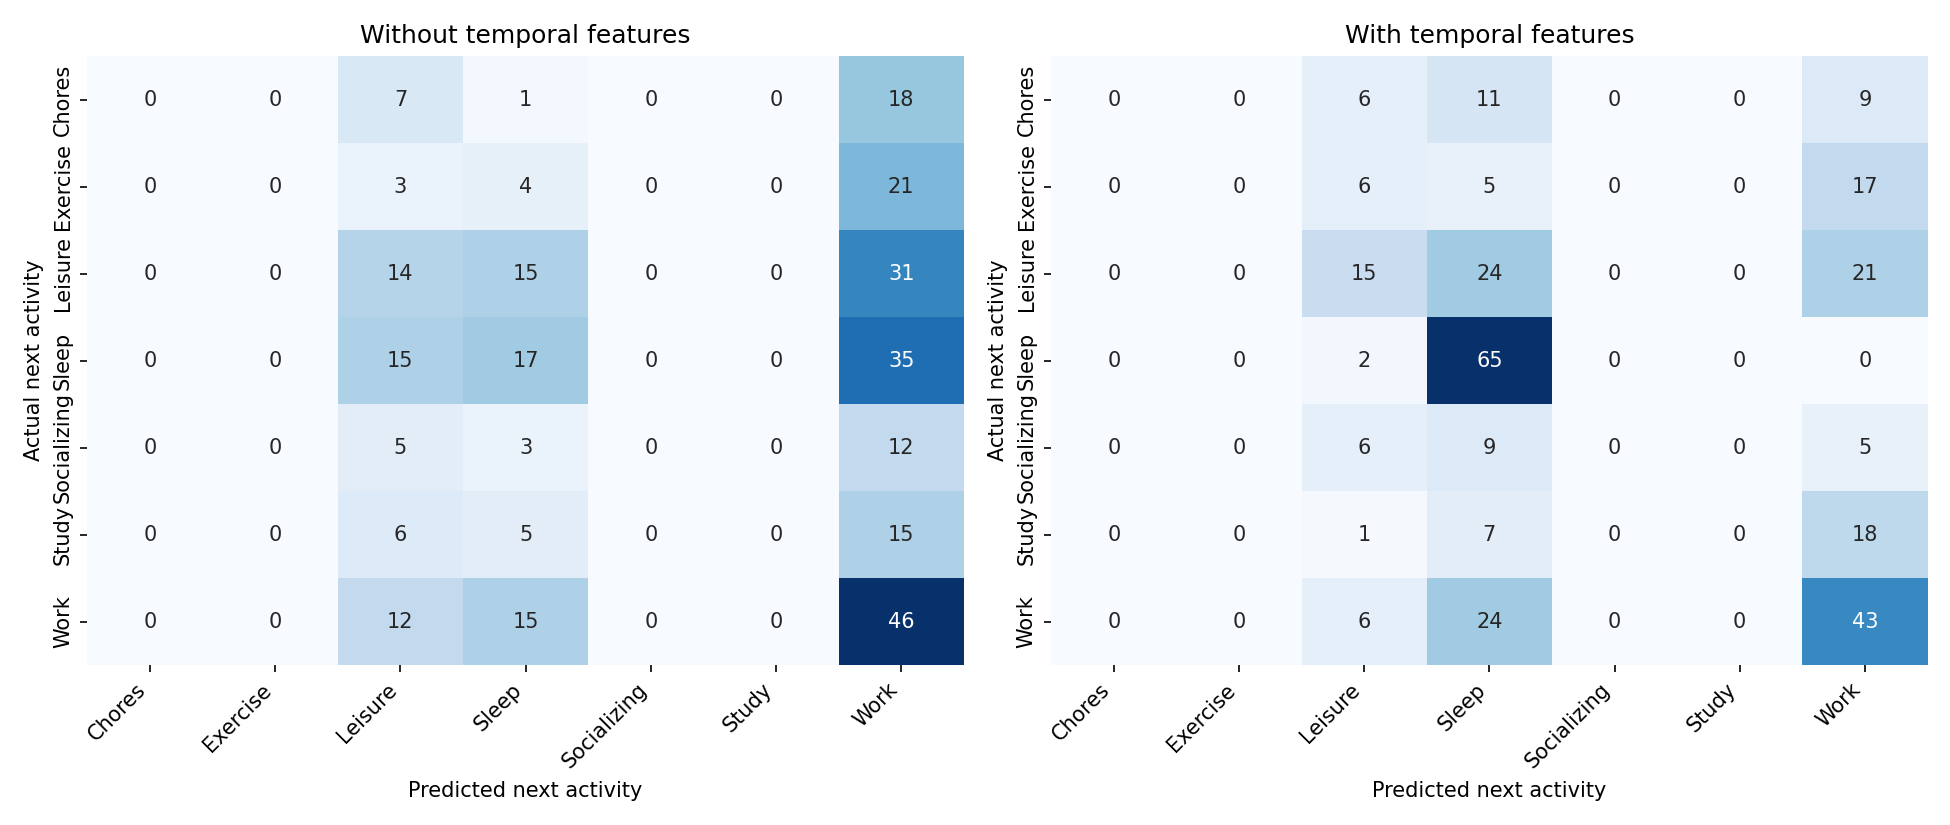

In [75]:
from IPython.display import Image, display
display(Image('/content/2_confusion_matrices.png'))